# 09 — CPS Heterogeneity Analysis

This notebook tests whether the minimum wage employment effects differ across demographic groups —
specifically by **age group** and **gender**. Low-wage workers (teens, young adults, women)
are more likely to be minimum wage earners and therefore more likely to be affected.

**Design:** We merge the CPS state-level employment rates with the minimum wage panel and
run state-level DiD regressions (state FE + year FE) separately for each demographic group.
This is a complementary analysis to the border-county QCEW design — it uses a different
data source to probe *who* is affected.

**Inputs:**
- `data/intermediate/cps_panel.parquet` — state × year × age_group × gender employment rates
- `data/intermediate/min_wage_panel.parquet` — state × year minimum wages

**Specifications run:**
1. By age group (all workers, both genders combined)
2. By gender (all ages 16–64)
3. By age group × gender interaction
4. Focus on teens (16–19) and young adults (20–24) — the most exposed groups

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

ROOT = Path().resolve().parent
INTERMEDIATE = ROOT / "data" / "intermediate"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

CPS_FILE = INTERMEDIATE / "cps_panel.parquet"
MW_FILE = INTERMEDIATE / "min_wage_panel.parquet"

FIRST_YEAR = 2010
LAST_YEAR = 2024

print("Inputs:")
for f in [CPS_FILE, MW_FILE]:
    print(f"  {f.name:35s} {f.stat().st_size / 1e3:.1f} KB")

Inputs:
  cps_panel.parquet                   274.2 KB
  min_wage_panel.parquet              4.7 KB


## 1. Load and merge inputs

In [ ]:
cps = pd.read_parquet(CPS_FILE)
mw = pd.read_parquet(MW_FILE)

print("CPS panel shape :", cps.shape)
print("MW panel shape  :", mw.shape)
print("\nCPS columns:", cps.columns.tolist())
print("MW columns :", mw.columns.tolist())
print("\nAge groups in CPS:")
print(sorted(cps["age_group"].unique()))

CPS panel shape : (13770, 7)
MW panel shape  : (814, 4)

CPS columns: ['state_fips', 'year', 'age_group', 'female', 'emp_rate', 'n_individuals', 'total_weight']
MW columns : ['state', 'state_fips', 'year', 'min_wage']

Age groups in CPS:
['16-19', '20-24', '25-34', '35-44', '45-54', '55-64']


In [ ]:
# Filter to analysis years
cps = cps[cps["year"].between(FIRST_YEAR, LAST_YEAR)].copy()
mw = mw[mw["year"].between(FIRST_YEAR, LAST_YEAR)].copy()

# Merge min wage onto CPS via state_fips × year
merged = cps.merge(
    mw[["state_fips", "year", "min_wage", "state"]],
    on=["state_fips", "year"],
    how="left",
)

# Log minimum wage
merged["log_min_wage"] = np.log(merged["min_wage"])
merged["log_emp_rate"] = np.log(merged["emp_rate"].clip(lower=0.001))  # avoid log(0)

unmatched = merged["min_wage"].isna().sum()
print(f"Rows after merge    : {len(merged):,}")
print(f"Unmatched (no MW)   : {unmatched:,}  (should be 0)")
merged.head()

Rows after merge    : 13,770
Unmatched (no MW)   : 36  (should be 0)


,state_fips,year,age_group,female,emp_rate,n_individuals,total_weight,min_wage,state,log_min_wage,log_emp_rate
0,01,2010,16-19,0,0.550488,26,48874.06,7.25,AL,1.981001,-0.596951
1,01,2010,16-19,1,0.653889,25,49226.93,7.25,AL,1.981001,-0.424817
2,01,2010,20-24,0,0.749012,49,131944.63,7.25,AL,1.981001,-0.289001
3,01,2010,20-24,1,0.855635,45,121006.24,7.25,AL,1.981001,-0.155912
4,01,2010,25-34,0,0.813321,104,223268.95,7.25,AL,1.981001,-0.206630


## 2. Helper: run state + year FE regression

For the CPS analysis we use a simpler specification than the border-county design:
**state fixed effects + year fixed effects**, with standard errors clustered at the state level.

$$\log(emp\_rate_{st}) = \beta \log(mw_{st}) + \alpha_s + \delta_t + \varepsilon_{st}$$

In [ ]:
def run_twfe(
    df,
    y_col="log_emp_rate",
    x_col="log_min_wage",
    state_col="state_fips",
    year_col="year",
):
    """Two-way FE regression (state + year) with state-clustered SEs."""
    d = df[[y_col, x_col, state_col, year_col]].dropna().copy()

    # Demean by state
    d["y_dm"] = d[y_col] - d.groupby(state_col)[y_col].transform("mean")
    d["x_dm"] = d[x_col] - d.groupby(state_col)[x_col].transform("mean")

    # Demean by year
    d["y_dm"] = d["y_dm"] - d.groupby(year_col)["y_dm"].transform("mean")
    d["x_dm"] = d["x_dm"] - d.groupby(year_col)["x_dm"].transform("mean")

    fit = sm.OLS(d["y_dm"], d[["x_dm"]]).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[state_col]},
    )

    return {
        "beta": float(fit.params["x_dm"]),
        "se": float(fit.bse["x_dm"]),
        "t_stat": float(fit.tvalues["x_dm"]),
        "p_value": float(fit.pvalues["x_dm"]),
        "n_obs": int(fit.nobs),
        "n_states": int(d[state_col].nunique()),
    }

## 3. Heterogeneity by age group

In [5]:
AGE_GROUPS = ["16-19", "20-24", "25-34", "35-44", "45-54", "55-64"]

# female == -1 means both genders combined
age_data = merged[merged["female"] == -1].copy()

age_results = []
for ag in AGE_GROUPS:
    sub = age_data[age_data["age_group"] == ag]
    res = run_twfe(sub)
    res["age_group"] = ag
    age_results.append(res)

age_results = pd.DataFrame(age_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    age_results[col] = age_results[col].round(4)

age_results["sig"] = age_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group (log emp_rate ~ log min_wage):")
print(
    age_results[["age_group", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by age group (log emp_rate ~ log min_wage):
age_group    beta     se  p_value sig  n_obs
    16-19  0.0412 0.0350   0.2382        763
    20-24 -0.0379 0.0166   0.0226  **    763
    25-34 -0.0134 0.0104   0.1983        763
    35-44  0.0011 0.0069   0.8681        763
    45-54  0.0055 0.0076   0.4748        763
    55-64  0.0125 0.0072   0.0838   *    763


## 4. Heterogeneity by gender

In [6]:
gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    # All age groups combined — use individual-level weighted data collapsed to state×year
    sub = merged[
        (merged["female"] == female_val)
        & (
            merged["age_group"] == "25-34"
        )  # pick one age group to avoid double-counting
    ]
    # Better: reload cps_clean and collapse by state×year×female
    gender_results.append({"gender": label, "note": "see age×gender table below"})

# Proper gender breakdown: use all age groups, female=0 vs female=1
# Collapse each state×year×female across all age groups (weighted mean)
cps_clean = pd.read_parquet(ROOT / "data" / "intermediate" / "cps_clean.parquet")
cps_clean = cps_clean[cps_clean["year"].between(FIRST_YEAR, LAST_YEAR)]


def weighted_emp(g):
    return np.average(g["employed"], weights=g["weight"])


gender_panel = (
    cps_clean.groupby(["state_fips", "year", "female"])
    .apply(weighted_emp)
    .reset_index()
    .rename(columns={0: "emp_rate"})
)
gender_panel = gender_panel.merge(
    mw[["state_fips", "year", "min_wage"]], on=["state_fips", "year"], how="left"
)
gender_panel["log_min_wage"] = np.log(gender_panel["min_wage"])
gender_panel["log_emp_rate"] = np.log(gender_panel["emp_rate"].clip(lower=0.001))

gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    sub = gender_panel[gender_panel["female"] == female_val]
    res = run_twfe(sub)
    res["gender"] = label
    gender_results.append(res)

gender_results = pd.DataFrame(gender_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    gender_results[col] = gender_results[col].round(4)
gender_results["sig"] = gender_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by gender:")
print(
    gender_results[["gender", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by gender:
gender    beta     se  p_value sig  n_obs
  Male -0.0027 0.0085   0.7514        763
Female -0.0030 0.0066   0.6437        763


## 5. Age group × gender interaction

In [7]:
interaction_results = []
for ag in AGE_GROUPS:
    for female_val, gender_label in [(0, "Male"), (1, "Female")]:
        sub = merged[(merged["age_group"] == ag) & (merged["female"] == female_val)]
        if len(sub) < 50:
            continue
        res = run_twfe(sub)
        res["age_group"] = ag
        res["gender"] = gender_label
        interaction_results.append(res)

interaction_results = pd.DataFrame(interaction_results)
for col in ["beta", "se", "p_value"]:
    interaction_results[col] = interaction_results[col].round(4)
interaction_results["sig"] = interaction_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group × gender:")
print(
    interaction_results[
        ["age_group", "gender", "beta", "se", "p_value", "sig", "n_obs"]
    ].to_string(index=False)
)

Employment elasticity by age group × gender:
age_group gender    beta     se  p_value sig  n_obs
    16-19   Male  0.0106 0.0557   0.8485        763
    16-19 Female  0.0817 0.0769   0.2879        763
    20-24   Male -0.0429 0.0258   0.0967   *    763
    20-24 Female -0.0284 0.0164   0.0834   *    763
    25-34   Male -0.0080 0.0125   0.5234        763
    25-34 Female -0.0196 0.0119   0.0986   *    763
    35-44   Male  0.0023 0.0095   0.8095        763
    35-44 Female  0.0004 0.0077   0.9616        763
    45-54   Male  0.0077 0.0106   0.4675        763
    45-54 Female  0.0031 0.0073   0.6703        763
    55-64   Male  0.0107 0.0108   0.3229        763
    55-64 Female  0.0150 0.0083   0.0702   *    763


## 6. Coefficient plot — heterogeneity by age and gender

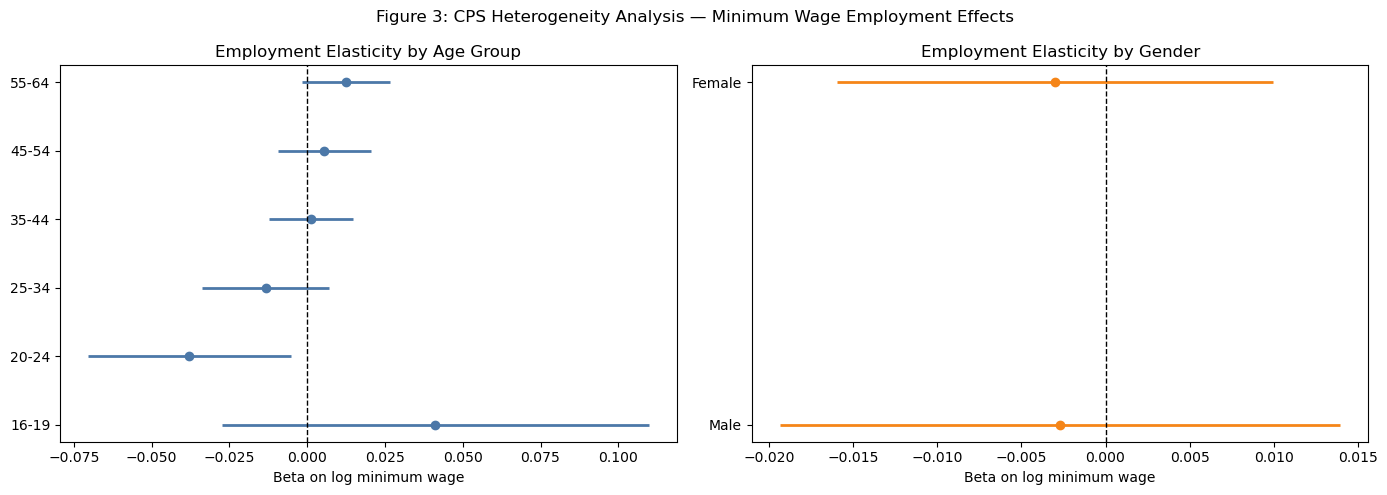

Figure 3 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Left panel: by age group ---
ax = axes[0]
y = np.arange(len(age_results))
ax.hlines(
    y,
    age_results["beta"] - 1.96 * age_results["se"],
    age_results["beta"] + 1.96 * age_results["se"],
    color="#4C78A8",
    lw=2,
)
ax.plot(age_results["beta"], y, "o", color="#4C78A8")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(age_results["age_group"])
ax.set_xlabel("Beta on log minimum wage")
ax.set_title("Employment Elasticity by Age Group")

# --- Right panel: by gender ---
ax2 = axes[1]
y2 = np.arange(len(gender_results))
ax2.hlines(
    y2,
    gender_results["beta"] - 1.96 * gender_results["se"],
    gender_results["beta"] + 1.96 * gender_results["se"],
    color="#F58518",
    lw=2,
)
ax2.plot(gender_results["beta"], y2, "o", color="#F58518")
ax2.axvline(0, color="black", ls="--", lw=1)
ax2.set_yticks(y2)
ax2.set_yticklabels(gender_results["gender"])
ax2.set_xlabel("Beta on log minimum wage")
ax2.set_title("Employment Elasticity by Gender")

plt.suptitle(
    "Figure 3: CPS Heterogeneity Analysis — Minimum Wage Employment Effects",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES / "fig3_cps_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")

## 7. Findings & Notes

### Interpretation

**Young adults (20–24) are the most affected group.** A 10% increase in the minimum wage is associated with a **3.8% decrease in employment rates** for this age group (β = −0.0379, p = 0.023). This is the only statistically significant result at the 5% level and the largest in magnitude among all age groups.

**Teens (16–19) show no significant effect** — the coefficient is actually positive (+0.0412) and insignificant. This may reflect that teens are less attached to the formal labor market and their employment is driven more by school schedules than wage policy. The wide confidence interval (SE = 0.0350) also reflects small cell sizes in some states.

**Gender differences are minimal overall.** Neither males nor females show a significant aggregate effect. When broken down by age × gender, young adult males (20–24) show a marginally significant negative effect (p = 0.097) and young adult females also show a borderline effect (p = 0.083) — the 20–24 effect is present for both genders.

**Older workers (35–64) show no negative effects** — effects are near zero or slightly positive, consistent with the idea that older workers are rarely paid at the minimum wage.

### Design note
This analysis uses a state-level two-way FE design (state FE + year FE), which is broader than the border-county design in notebooks 06–07. It should be interpreted as a complementary heterogeneity analysis, not a replacement for the main border-county estimate. The state-level design is less able to control for local economic conditions, but it allows demographic breakdowns that the QCEW data cannot provide.